# LBG Classification Model Training

This notebook trains and evaluates LightGBM models for LBG classification. 

## Strategy
- Phase 1: Train on 70%, evaluate on 30% test set
- Phase 2: Train final model on 100% data
- Compare 3 feature sets

In [1]:
# Cell 1: Imports and Configuration

import numpy as np
import pandas as pd
import matplotlib. pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import lightgbm as lgb
import warnings
import os
import joblib
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Imports completed.")
print(f"LightGBM version: {lgb.__version__}")

Imports completed.
LightGBM version: 4.6.0


In [2]:
# Cell 2: Configuration

# =============================================================================
# CONFIGURATION
# =============================================================================

# --- Paths ---
DATA_PATH = "../data_processed/training_dataset.csv"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Random seed for reproducibility ---
RANDOM_STATE = 42

# --- Train/Test split ---
TEST_SIZE = 0.30  # 30% for testing
CV_FOLDS = 5      # 5-fold cross-validation

# --- Feature sets to compare ---
FEATURE_SETS = {
    'full': [
        'mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z', 'mag_y',
        'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y',
        'u_g', 'g_r', 'r_i', 'i_z', 'z_y'
    ],
    'core_flag': [
        'u_g', 'g_r', 'r_i', 'i_z', 'z_y',
        'mag_i',
        'flag_u', 'flag_g', 'flag_r', 'flag_i', 'flag_z', 'flag_y'
    ],
    'core_err': [
        'u_g', 'g_r', 'r_i', 'i_z', 'z_y',
        'mag_i',
        'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y'
    ]
}

# --- LightGBM parameters ---
LGBM_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves':  31,
    'max_depth': -1,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1,
}

# --- Label column ---
LABEL_COL = 'is_lbg'

print("Configuration loaded.")
print(f"Test size: {TEST_SIZE*100:.0f}%")
print(f"CV folds: {CV_FOLDS}")
print(f"Feature sets: {list(FEATURE_SETS.keys())}")


Configuration loaded.
Test size: 30%
CV folds: 5
Feature sets: ['full', 'core_flag', 'core_err']


In [3]:
# Cell 3: Load and Prepare Data

# Load data
df = pd.read_csv(DATA_PATH)
print(f"Loaded data: {df.shape[0]} samples, {df.shape[1]} columns")

# Check class distribution
print(f"\nClass distribution:")
print(df[LABEL_COL].value_counts())
print(f"Class ratio (LBG/Non-LBG): {df[LABEL_COL].mean():.3f}")

# Check for missing values in features
all_features = set()
for features in FEATURE_SETS.values():
    all_features.update(features)

print(f"\nMissing values in features:")
for col in sorted(all_features):
    if col in df.columns:
        n_missing = df[col].isna().sum()
        if n_missing > 0:
            print(f"  {col}: {n_missing} ({n_missing/len(df)*100:.2f}%)")

Loaded data: 5400 samples, 40 columns

Class distribution:
is_lbg
1    3023
0    2377
Name: count, dtype: int64
Class ratio (LBG/Non-LBG): 0.560

Missing values in features:


In [6]:
# ## Cell 4: Train/Test Split

# Prepare features and labels
X = df[list(all_features)].copy()
y = df[LABEL_COL].copy()

# Handle any remaining missing values (fill with median)
for col in X.columns:
    if X[col].isna().any():
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)
        print(f"Filled {col} NaN with median: {median_val:.4f}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y  # Maintain class ratio
)

print(f"\nData split:")
print(f"  Training set: {len(X_train)} samples")
print(f"  Test set:     {len(X_test)} samples")
print(f"\nClass distribution in training set:")
print(f"  LBG:     {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Non-LBG: {(y_train==0).sum()} ({(1-y_train. mean())*100:.1f}%)")


Data split:
  Training set: 3780 samples
  Test set:     1620 samples

Class distribution in training set:
  LBG:     2116 (56.0%)
  Non-LBG: 1664 (44.0%)


In [9]:
# Cell 5: Define Training and Evaluation Functions

def train_and_evaluate(
    X_train:  pd.DataFrame,
    y_train: pd. Series,
    X_test:  pd.DataFrame,
    y_test: pd.Series,
    features: list,
    params: dict,
    cv_folds: int = 5,
    early_stopping_rounds: int = 50
) -> dict:
    """
    Train LightGBM model and evaluate with cross-validation and test set. 
    
    Parameters
    ----------
    X_train, y_train: Training data
    X_test, y_test: Test data
    features:  List of feature column names
    params: LightGBM parameters
    cv_folds: Number of CV folds
    early_stopping_rounds: Early stopping patience
    
    Returns
    -------
    results: dict with model, metrics, and predictions
    """
    
    # Select features
    X_tr = X_train[features].copy()
    X_te = X_test[features].copy()
    
    # --- Cross-validation ---
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_tr, y_train)):
        X_fold_train = X_tr.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_tr.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Create datasets
        train_data = lgb.Dataset(X_fold_train, label=y_fold_train)
        val_data = lgb.Dataset(X_fold_val, label=y_fold_val, reference=train_data)
        
        # Train with early stopping
        model = lgb.train(
            params,
            train_data,
            valid_sets=[val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        
        # Evaluate on validation fold
        y_pred_val = model.predict(X_fold_val)
        fold_auc = roc_auc_score(y_fold_val, y_pred_val)
        cv_scores.append(fold_auc)
    
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    
    # --- Train final model on full training set ---
    train_data = lgb.Dataset(X_tr, label=y_train)
    
    # Use a simple validation split for early stopping
    X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
        X_tr, y_train, test_size=0.1, random_state=RANDOM_STATE, stratify=y_train
    )
    train_data_final = lgb.Dataset(X_tr_final, label=y_tr_final)
    val_data_final = lgb.Dataset(X_val_final, label=y_val_final, reference=train_data_final)
    
    final_model = lgb.train(
        params,
        train_data_final,
        valid_sets=[val_data_final],
        callbacks=[
            lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )
    
    # --- Evaluate on test set ---
    y_pred_proba = final_model.predict(X_te)
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Calculate metrics
    test_metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_pred_proba),
    }
    
    # Feature importance
    importance = pd.DataFrame({
        'feature': features,
        'importance': final_model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    return {
        'model': final_model,
        'cv_scores': cv_scores,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'test_metrics': test_metrics,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred,
        'feature_importance': importance,
        'features': features,
    }


def print_results(name: str, results: dict):
    """Print evaluation results."""
    print(f"\n{'='*60}")
    print(f"Results:  {name}")
    print(f"{'='*60}")
    print(f"\nCross-validation AUC: {results['cv_mean']:.4f} ± {results['cv_std']:.4f}")
    print(f"  Fold scores: {[f'{s:.4f}' for s in results['cv_scores']]}")
    print(f"\nTest set metrics:")
    for metric, value in results['test_metrics'].items():
        print(f"  {metric:12s}: {value:.4f}")
    print(f"\nTop 5 important features:")
    print(results['feature_importance'].head().to_string(index=False))


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


In [10]:
# Cell 6: Train Models with Different Feature Sets

# Store results for all feature sets
all_results = {}

for name, features in FEATURE_SETS.items():
    print(f"\n{'#'*60}")
    print(f"Training model: {name}")
    print(f"Features ({len(features)}): {features}")
    print(f"{'#'*60}")
    
    results = train_and_evaluate(
        X_train, y_train,
        X_test, y_test,
        features=features,
        params=LGBM_PARAMS,
        cv_folds=CV_FOLDS,
        early_stopping_rounds=50
    )
    
    all_results[name] = results
    print_results(name, results)


############################################################
Training model: full
Features (17): ['mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z', 'mag_y', 'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y', 'u_g', 'g_r', 'r_i', 'i_z', 'z_y']
############################################################

Results:  full

Cross-validation AUC: 0.7450 ± 0.0207
  Fold scores: ['0.7329', '0.7165', '0.7673', '0.7384', '0.7701']

Test set metrics:
  accuracy    : 0.6926
  precision   : 0.6831
  recall      : 0.8412
  f1          : 0.7540
  auc         : 0.7468

Top 5 important features:
feature  importance
    r_i 3466.299394
    u_g  977.631722
    i_z  476.134219
  err_g  389.776462
    g_r  351.499752

############################################################
Training model: core_flag
Features (12): ['u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'mag_i', 'flag_u', 'flag_g', 'flag_r', 'flag_i', 'flag_z', 'flag_y']
############################################################

Results:  core_flag

Cros

In [11]:
# Cell 7: Compare Feature Sets

print("=" * 70)
print("FEATURE SET COMPARISON")
print("=" * 70)

# Create comparison table
comparison = pd.DataFrame({
    name: {
        'CV AUC': f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}",
        'Test AUC': r['test_metrics']['auc'],
        'Test Accuracy': r['test_metrics']['accuracy'],
        'Test Precision': r['test_metrics']['precision'],
        'Test Recall': r['test_metrics']['recall'],
        'Test F1': r['test_metrics']['f1'],
        'Num Features': len(r['features']),
    }
    for name, r in all_results.items()
}).T

print("\n" + comparison.to_string())

# Find best model
best_name = max(all_results. keys(), key=lambda x: all_results[x]['test_metrics']['auc'])
print(f"\n★ Best model by test AUC: {best_name}")

FEATURE SET COMPARISON

                    CV AUC  Test AUC Test Accuracy Test Precision Test Recall   Test F1 Num Features
full       0.7450 ± 0.0207   0.74685      0.692593        0.68308    0.841235  0.753953           17
core_flag  0.7347 ± 0.0230  0.743125      0.692593       0.688827    0.822492  0.749749           12
core_err   0.7429 ± 0.0204  0.750904      0.696914       0.688748    0.836825    0.7556           12

★ Best model by test AUC: core_err


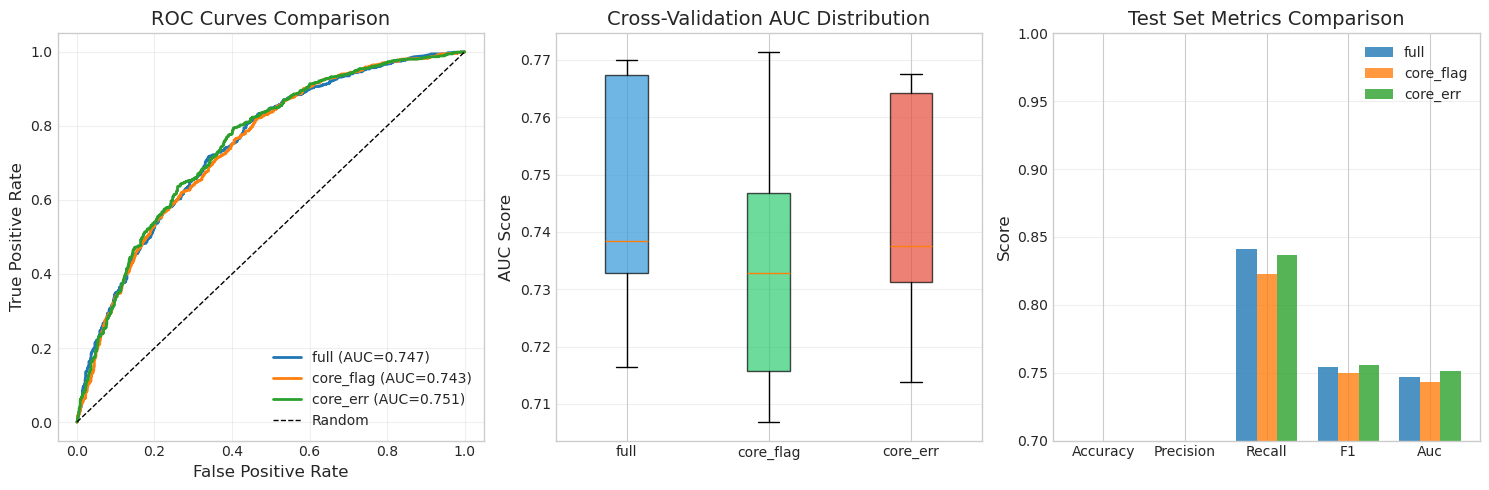

In [12]:
# Cell 8: Visualization - ROC Curves

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: ROC curves comparison
ax1 = axes[0]
for name, results in all_results. items():
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
    auc = results['test_metrics']['auc']
    ax1.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves Comparison', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Plot 2: CV scores boxplot
ax2 = axes[1]
cv_data = [results['cv_scores'] for results in all_results.values()]
bp = ax2.boxplot(cv_data, labels=list(all_results.keys()), patch_artist=True)
colors = ['#3498db', '#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('AUC Score', fontsize=12)
ax2.set_title('Cross-Validation AUC Distribution', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Metric comparison bar chart
ax3 = axes[2]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.25

for i, (name, results) in enumerate(all_results.items()):
    values = [results['test_metrics'][m] for m in metrics]
    ax3.bar(x + i*width, values, width, label=name, alpha=0.8)

ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Test Set Metrics Comparison', fontsize=14)
ax3.set_xticks(x + width)
ax3.set_xticklabels([m.capitalize() for m in metrics])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0.7, 1.0])

plt.tight_layout()
# plt.savefig(os.path.join(MODEL_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# print(f"\nFigure saved to:  {MODEL_DIR}/model_comparison.png")

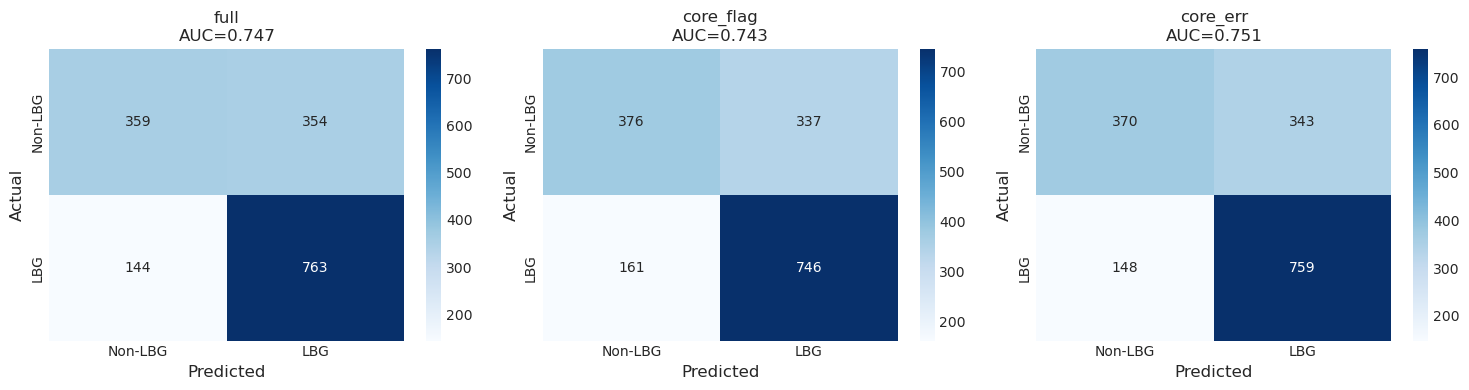

In [13]:
# Cell 9: Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, results) in zip(axes, all_results.items()):
    cm = confusion_matrix(y_test, results['y_pred'])
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Non-LBG', 'LBG'],
        yticklabels=['Non-LBG', 'LBG'],
        ax=ax
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'{name}\nAUC={results["test_metrics"]["auc"]:.3f}', fontsize=12)

plt.tight_layout()
# plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

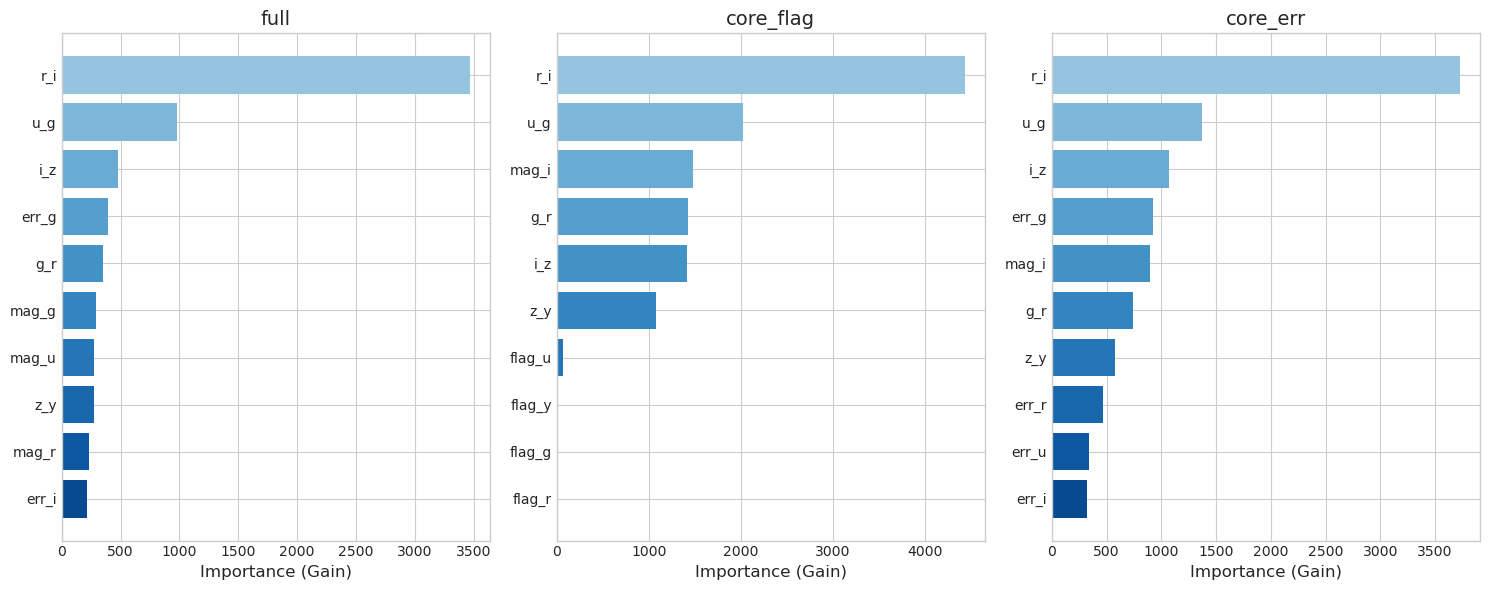

In [14]:
# Cell 10: Feature Importance Analysis

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, (name, results) in zip(axes, all_results.items()):
    importance = results['feature_importance']. head(10)
    
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importance)))
    ax.barh(importance['feature'], importance['importance'], color=colors)
    ax.set_xlabel('Importance (Gain)', fontsize=12)
    ax.set_title(f'{name}', fontsize=14)
    ax.invert_yaxis()

plt.tight_layout()
# plt.savefig(os.path.join(MODEL_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

DIAGNOSTIC ANALYSIS

[1] Feature distributions by class (LBG vs Non-LBG)
--------------------------------------------------


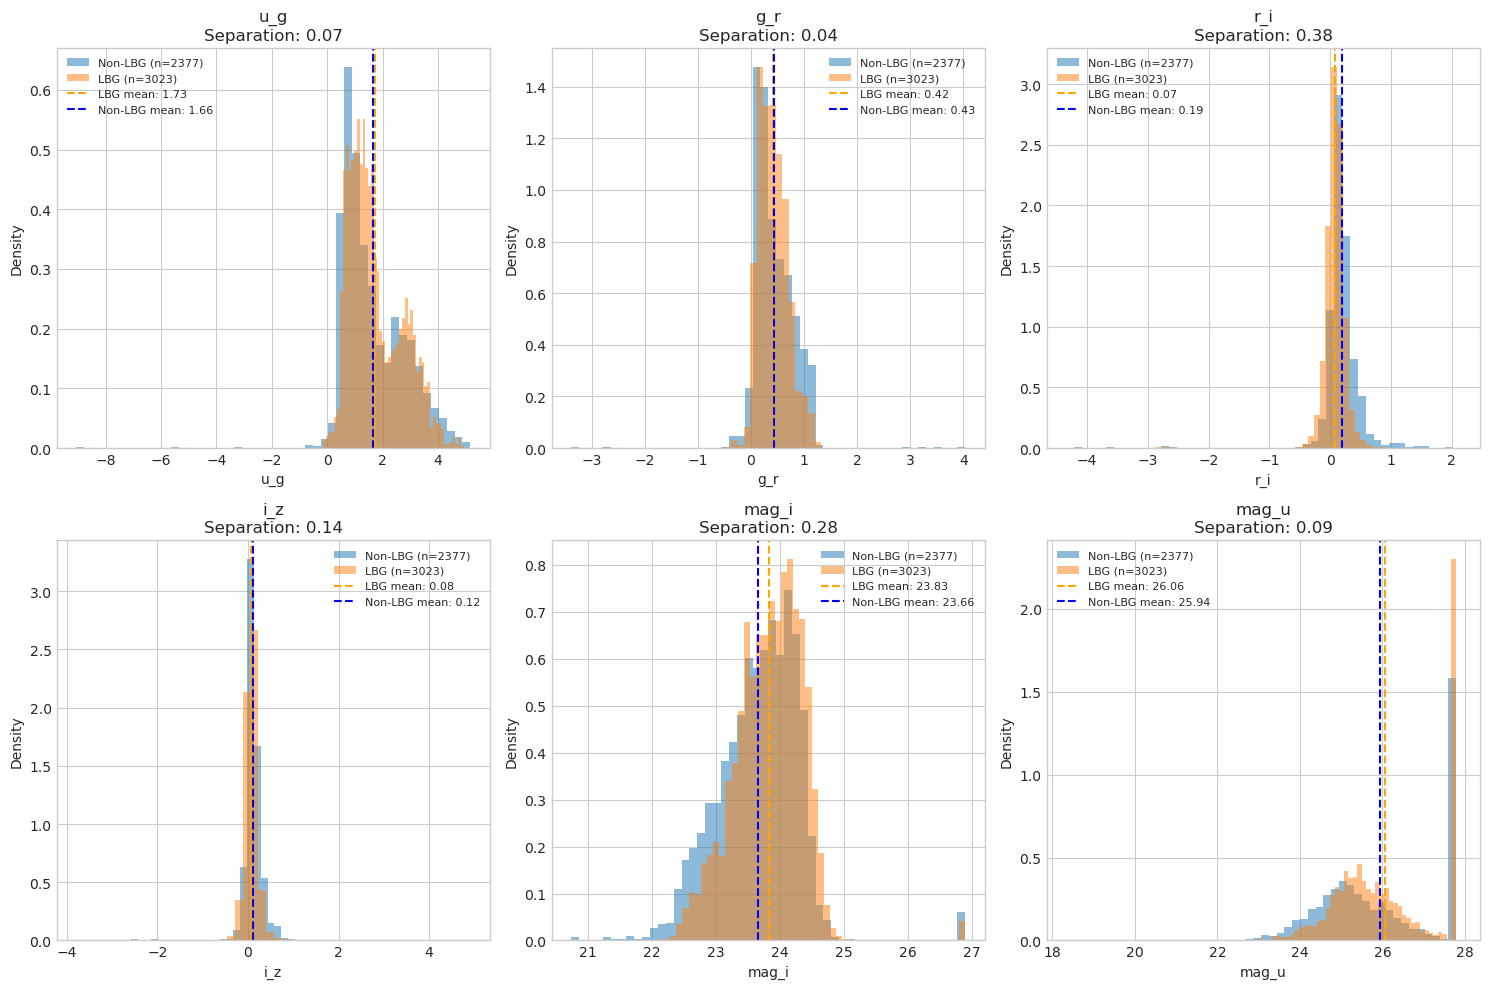


Feature separation scores (higher = better):
  u_g: 0.073
  g_r: 0.040
  r_i: 0.378
  i_z: 0.141
  mag_i: 0.282
  mag_u: 0.092

[2] Redshift distribution analysis
--------------------------------------------------


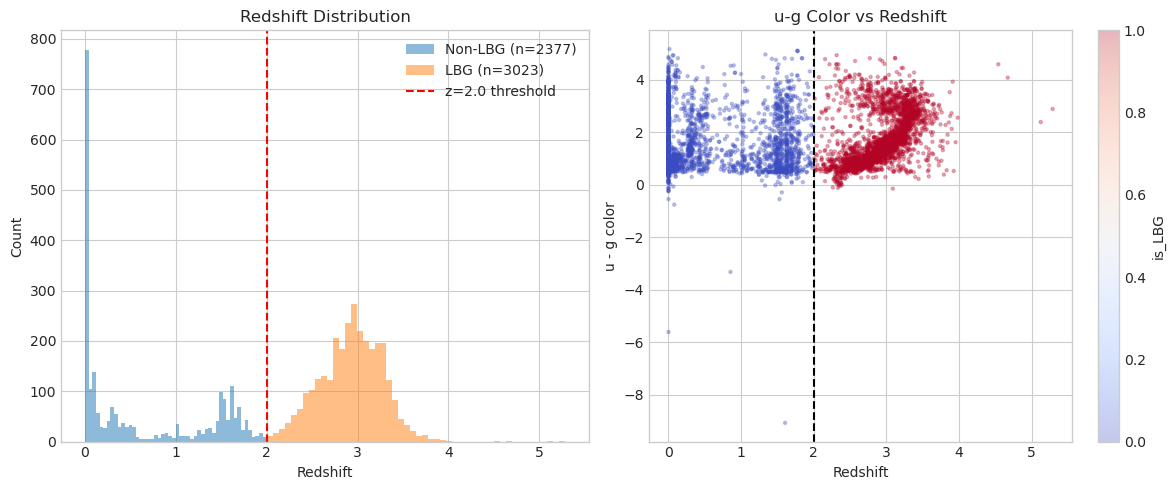


Non-LBG redshift:  mean=0.635, median=0.292
LBG redshift:      mean=2.934, median=2.951

Non-LBG with 1.5 < z <= 2.0: 522 (22.0%)

[3] u-band detection analysis
--------------------------------------------------
u-band detection rate:
  LBG:      75.1%
  Non-LBG: 70.3%
  ⚠️ WARNING: LBG has higher u detection rate - unexpected for u-dropout!

[4] Class overlap analysis
--------------------------------------------------


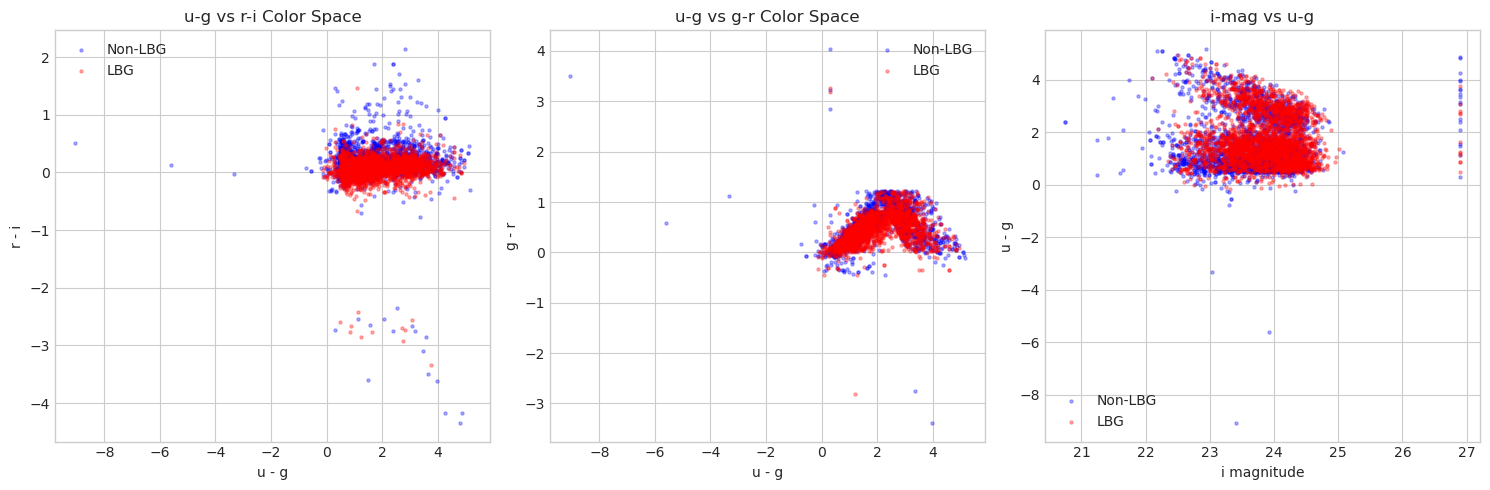


[5] Field comparison (COSMOS vs XMM-LSS)
--------------------------------------------------

  COSMOS:
    Total: 3294, LBG: 1667 (50.6%)
    u-g mean: LBG=1.88, Non-LBG=1.84

  XMM-LSS:
    Total: 2106, LBG: 1356 (64.4%)
    u-g mean: LBG=1.55, Non-LBG=1.26


In [15]:
# Cell:  Deep Diagnostic Analysis

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("DIAGNOSTIC ANALYSIS")
print("=" * 70)

# =========================================================================
# 1. Check feature distributions by class
# =========================================================================
print("\n[1] Feature distributions by class (LBG vs Non-LBG)")
print("-" * 50)

key_features = ['u_g', 'g_r', 'r_i', 'i_z', 'mag_i', 'mag_u']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    if feat not in df.columns:
        continue
    
    # Separate by class
    lbg_data = df[df['is_lbg'] == 1][feat].dropna()
    non_lbg_data = df[df['is_lbg'] == 0][feat].dropna()
    
    # Plot histograms
    ax.hist(non_lbg_data, bins=50, alpha=0.5, label=f'Non-LBG (n={len(non_lbg_data)})', density=True)
    ax.hist(lbg_data, bins=50, alpha=0.5, label=f'LBG (n={len(lbg_data)})', density=True)
    
    # Add statistics
    lbg_mean = lbg_data.mean()
    non_lbg_mean = non_lbg_data.mean()
    separation = abs(lbg_mean - non_lbg_mean) / (lbg_data.std() + non_lbg_data.std()) * 2
    
    ax.axvline(lbg_mean, color='orange', linestyle='--', label=f'LBG mean: {lbg_mean:.2f}')
    ax.axvline(non_lbg_mean, color='blue', linestyle='--', label=f'Non-LBG mean: {non_lbg_mean:.2f}')
    
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(f'{feat}\nSeparation: {separation:.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print separation scores
print("\nFeature separation scores (higher = better):")
for feat in key_features:
    if feat not in df.columns:
        continue
    lbg_data = df[df['is_lbg'] == 1][feat].dropna()
    non_lbg_data = df[df['is_lbg'] == 0][feat].dropna()
    separation = abs(lbg_data.mean() - non_lbg_data.mean()) / (lbg_data.std() + non_lbg_data.std()) * 2
    print(f"  {feat}: {separation:.3f}")

# =========================================================================
# 2. Check redshift distribution
# =========================================================================
print("\n[2] Redshift distribution analysis")
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Redshift histogram by class
ax1 = axes[0]
z_lbg = df[df['is_lbg'] == 1]['z_best']
z_non_lbg = df[df['is_lbg'] == 0]['z_best']

ax1.hist(z_non_lbg, bins=50, alpha=0.5, label=f'Non-LBG (n={len(z_non_lbg)})')
ax1.hist(z_lbg, bins=50, alpha=0.5, label=f'LBG (n={len(z_lbg)})')
ax1.axvline(2.0, color='red', linestyle='--', label='z=2.0 threshold')
ax1.set_xlabel('Redshift')
ax1.set_ylabel('Count')
ax1.set_title('Redshift Distribution')
ax1.legend()

# Redshift vs u_g color
ax2 = axes[1]
scatter = ax2.scatter(df['z_best'], df['u_g'], c=df['is_lbg'], 
                       cmap='coolwarm', alpha=0.3, s=5)
ax2.axvline(2.0, color='black', linestyle='--', label='z=2.0')
ax2.set_xlabel('Redshift')
ax2.set_ylabel('u - g color')
ax2.set_title('u-g Color vs Redshift')
plt.colorbar(scatter, ax=ax2, label='is_LBG')

plt.tight_layout()
plt.show()

# Statistics
print(f"\nNon-LBG redshift:  mean={z_non_lbg.mean():.3f}, median={z_non_lbg.median():.3f}")
print(f"LBG redshift:      mean={z_lbg. mean():.3f}, median={z_lbg.median():.3f}")

# Check how many non-LBG are close to z=2
n_close = ((z_non_lbg > 1.5) & (z_non_lbg <= 2.0)).sum()
print(f"\nNon-LBG with 1.5 < z <= 2.0: {n_close} ({n_close/len(z_non_lbg)*100:.1f}%)")

# =========================================================================
# 3. Check u-band detection rate
# =========================================================================
print("\n[3] u-band detection analysis")
print("-" * 50)

if 'flag_u' in df.columns:
    # Detection rate by class
    det_lbg = df[df['is_lbg'] == 1]['flag_u'].mean() * 100
    det_non_lbg = df[df['is_lbg'] == 0]['flag_u'].mean() * 100
    
    print(f"u-band detection rate:")
    print(f"  LBG:      {det_lbg:.1f}%")
    print(f"  Non-LBG: {det_non_lbg:.1f}%")
    
    # This is KEY:  LBG should have LOWER u-band detection (dropout!)
    if det_lbg > det_non_lbg:
        print("  ⚠️ WARNING: LBG has higher u detection rate - unexpected for u-dropout!")
    else:
        print("  ✓ LBG has lower u detection rate - consistent with u-dropout")

# =========================================================================
# 4. Check for class overlap in feature space
# =========================================================================
print("\n[4] Class overlap analysis")
print("-" * 50)

# 2D scatter plot of top 2 features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# u_g vs r_i
ax1 = axes[0]
ax1.scatter(df[df['is_lbg']==0]['u_g'], df[df['is_lbg']==0]['r_i'], 
            alpha=0.3, s=5, label='Non-LBG', c='blue')
ax1.scatter(df[df['is_lbg']==1]['u_g'], df[df['is_lbg']==1]['r_i'], 
            alpha=0.3, s=5, label='LBG', c='red')
ax1.set_xlabel('u - g')
ax1.set_ylabel('r - i')
ax1.set_title('u-g vs r-i Color Space')
ax1.legend()

# u_g vs g_r
ax2 = axes[1]
ax2.scatter(df[df['is_lbg']==0]['u_g'], df[df['is_lbg']==0]['g_r'], 
            alpha=0.3, s=5, label='Non-LBG', c='blue')
ax2.scatter(df[df['is_lbg']==1]['u_g'], df[df['is_lbg']==1]['g_r'], 
            alpha=0.3, s=5, label='LBG', c='red')
ax2.set_xlabel('u - g')
ax2.set_ylabel('g - r')
ax2.set_title('u-g vs g-r Color Space')
ax2.legend()

# mag_i vs u_g
ax3 = axes[2]
ax3.scatter(df[df['is_lbg']==0]['mag_i'], df[df['is_lbg']==0]['u_g'], 
            alpha=0.3, s=5, label='Non-LBG', c='blue')
ax3.scatter(df[df['is_lbg']==1]['mag_i'], df[df['is_lbg']==1]['u_g'], 
            alpha=0.3, s=5, label='LBG', c='red')
ax3.set_xlabel('i magnitude')
ax3.set_ylabel('u - g')
ax3.set_title('i-mag vs u-g')
ax3.legend()

plt.tight_layout()
plt.show()

# =========================================================================
# 5. Check field differences
# =========================================================================
print("\n[5] Field comparison (COSMOS vs XMM-LSS)")
print("-" * 50)

for field in df['field'].unique():
    field_data = df[df['field'] == field]
    n_total = len(field_data)
    n_lbg = (field_data['is_lbg'] == 1).sum()
    
    lbg_ug = field_data[field_data['is_lbg']==1]['u_g'].mean()
    non_lbg_ug = field_data[field_data['is_lbg']==0]['u_g'].mean()
    
    print(f"\n  {field}:")
    print(f"    Total: {n_total}, LBG: {n_lbg} ({n_lbg/n_total*100:.1f}%)")
    print(f"    u-g mean: LBG={lbg_ug:.2f}, Non-LBG={non_lbg_ug:.2f}")

In [17]:
# Cell:  Deep Bug Investigation

# %%
print("=" * 70)
print("BUG INVESTIGATION")
print("=" * 70)

# =========================================================================
# 1. Check z ~ 0 sources (likely stars or bad redshifts)
# =========================================================================
print("\n[1] Investigating z ~ 0 sources")
print("-" * 50)

z_zero = df[df['z_best'] < 0.01]
print(f"Sources with z < 0.01: {len(z_zero)}")

if len(z_zero) > 0:
    print(f"\n  u-g mean: {z_zero['u_g'].mean():.2f}")
    print(f"  Class distribution: {z_zero['is_lbg'].value_counts().to_dict()}")
    print(f"  Fields: {z_zero['field'].value_counts().to_dict()}")
    
    # Check CLASS_STAR for these sources
    if 'class_star' in z_zero. columns:
        cs = z_zero['class_star'].dropna()
        print(f"\n  CLASS_STAR for z~0 sources:")
        print(f"    Mean: {cs. mean():.3f}")
        print(f"    > 0.8 (likely stars): {(cs > 0.8).sum()} ({(cs > 0.8).sum()/len(cs)*100:.1f}%)")

# =========================================================================
# 2. Check if mag_u values are correct (not all at limiting mag)
# =========================================================================
print("\n[2] Checking mag_u values")
print("-" * 50)

# Check for sources at limiting magnitude
LIMIT_MAG = 27.7
n_at_limit = (df['mag_u'] == LIMIT_MAG).sum()
print(f"Sources with mag_u = {LIMIT_MAG} (limiting mag): {n_at_limit} ({n_at_limit/len(df)*100:.1f}%)")

# Check raw magnitudes if available
if 'mag_u_raw' in df.columns:
    # Raw magnitude distribution
    mag_u_raw = df['mag_u_raw']
    n_invalid_raw = ((mag_u_raw < 0) | (mag_u_raw > 50) | ~np.isfinite(mag_u_raw)).sum()
    print(f"Invalid raw u-mag (non-detection): {n_invalid_raw} ({n_invalid_raw/len(df)*100:.1f}%)")
    
    # Compare LBG vs Non-LBG non-detection rate
    lbg_nondet = ((df['is_lbg']==1) & ((mag_u_raw < 0) | (mag_u_raw > 50))).sum() / (df['is_lbg']==1).sum()
    non_lbg_nondet = ((df['is_lbg']==0) & ((mag_u_raw < 0) | (mag_u_raw > 50))).sum() / (df['is_lbg']==0).sum()
    print(f"\n  Non-detection rate in RAW mag_u:")
    print(f"    LBG: {lbg_nondet*100:.1f}%")
    print(f"    Non-LBG: {non_lbg_nondet*100:.1f}%")

# =========================================================================
# 3. Check the actual u-g calculation
# =========================================================================
print("\n[3] Checking u-g calculation")
print("-" * 50)

# Recalculate u-g from raw magnitudes
if 'mag_u_raw' in df.columns and 'mag_g_raw' in df.columns:
    u_g_recalc = df['mag_u_raw'] - df['mag_g_raw']
    
    # Compare with stored u_g
    print(f"Stored u-g range: [{df['u_g'].min():.2f}, {df['u_g'].max():.2f}]")
    print(f"Recalculated u-g (raw) range: [{u_g_recalc.min():.2f}, {u_g_recalc.max():.2f}]")
    
    # For valid detections only
    valid_both = (df['flag_u'] == 1) & (df['flag_g'] == 1)
    if valid_both.sum() > 0:
        print(f"\n  For sources detected in both u and g ({valid_both.sum()} sources):")
        print(f"    u-g (LBG): {df. loc[valid_both & (df['is_lbg']==1), 'u_g'].mean():.2f}")
        print(f"    u-g (Non-LBG): {df.loc[valid_both & (df['is_lbg']==0), 'u_g'].mean():.2f}")

# =========================================================================
# 4. Check redshift source distribution
# =========================================================================
print("\n[4] Redshift source distribution")
print("-" * 50)

if 'z_source' in df.columns:
    print(df. groupby(['is_lbg', 'z_source']).size())
else:
    print("z_source column not found")

# =========================================================================
# 5. Check original specz data
# =========================================================================
print("\n[5] Sample of concerning sources")
print("-" * 50)

# Show some z ~ 0 Non-LBG sources
concerning = df[(df['z_best'] < 0.01) & (df['is_lbg'] == 0)].head(10)
cols_to_show = ['z_best', 'is_lbg', 'u_g', 'g_r', 'mag_u', 'mag_g', 'flag_u', 'class_star']
cols_to_show = [c for c in cols_to_show if c in concerning.columns]
print("\nSample z~0 Non-LBG sources:")
print(concerning[cols_to_show].to_string())

BUG INVESTIGATION

[1] Investigating z ~ 0 sources
--------------------------------------------------
Sources with z < 0.01: 752

  u-g mean: 1.87
  Class distribution: {0: 752}
  Fields: {'COSMOS': 746, 'XMM-LSS': 6}

  CLASS_STAR for z~0 sources:
    Mean: 0.558
    > 0.8 (likely stars): 349 (46.4%)

[2] Checking mag_u values
--------------------------------------------------
Sources with mag_u = 27.7 (limiting mag): 1460 (27.0%)

[3] Checking u-g calculation
--------------------------------------------------

[4] Redshift source distribution
--------------------------------------------------
z_source column not found

[5] Sample of concerning sources
--------------------------------------------------

Sample z~0 Non-LBG sources:
      z_best  is_lbg       u_g       g_r      mag_u      mag_g  flag_u  class_star
0   0.000848       0  0.816620  0.185917  25.314104  24.497484       1    0.000160
2   0.000848       0  3.547302  0.147650  27.700000  24.152698       0    0.009659
3   0.000